# Выпускная работа

# Часть первая: Исследовательский анализ данных

## План работы
- Загрузим датасет для анализа
- Исправим занчения в датасете
- Извлечём числовые данные из текстовых
- Проведём корреляционный анализ данных и построим регрессии данных
- Интерпретируемы результаты анализа
- Проведём лексический анализ данных
- Интерпретируемы результаты анализа
- Подготовим выводы по аналитической работе

Датасет для аналитической работы взят на [kaggle.com](https://www.kaggle.com/datasets/rashikrahmanpritom/data-science-job-posting-on-glassdoor).

Он содержит данные о рекрутинге персонала на должность аналитика данных. Данные для датасета получены с сайта [glassdoor.com](https://www.glassdoor.com/index.htm) за 2021 год.

## 1 Загрузка датасета

Загрузим датасет в среду выполнения и дадим преварительную характеристику.

Для загрузки датасета необходимо скачать датасет по [ссылке](https://www.kaggle.com/datasets/rashikrahmanpritom/data-science-job-posting-on-glassdoor/download?datasetVersionNumber=1). Затем его нужно распаковать и загрузить файл Uncleaned_DS_jobs.csv в Файлы блокнота.

In [ ]:
# Импортируем необходимые библиотеки для работы с датасетами
import numpy as np
import pandas as pd

pd.set_option('future.no_silent_downcasting', True)

df = pd.read_csv('Uncleaned_DS_jobs.csv')  # Преобразуем датасет, имеющий формат csv, в DataFrame

df.head(10)  # Выведем первые 10 строк данных датасета

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"
5,5,Data Scientist,$137K-$171K (Glassdoor est.),About Us:\n\nHeadquartered in beautiful Santa ...,4.2,HG Insights\n4.2,"Santa Barbara, CA","Santa Barbara, CA",51 to 200 employees,2010,Company - Private,Computer Hardware & Software,Information Technology,Unknown / Non-Applicable,-1
6,6,Data Scientist / Machine Learning Expert,$137K-$171K (Glassdoor est.),Posting Title\nData Scientist / Machine Learni...,3.9,Novartis\n3.9,"Cambridge, MA","Basel, Switzerland",10000+ employees,1996,Company - Public,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,$10+ billion (USD),-1
7,7,Data Scientist,$137K-$171K (Glassdoor est.),Introduction\n\nHave you always wanted to run ...,3.5,iRobot\n3.5,"Bedford, MA","Bedford, MA",1001 to 5000 employees,1990,Company - Public,Consumer Electronics & Appliances Stores,Retail,$1 to $2 billion (USD),-1
8,8,Staff Data Scientist - Analytics,$137K-$171K (Glassdoor est.),Intuit is seeking a Staff Data Scientist to co...,4.4,Intuit - Data\n4.4,"San Diego, CA","Mountain View, CA",5001 to 10000 employees,1983,Company - Public,Computer Hardware & Software,Information Technology,$2 to $5 billion (USD),"Square, PayPal, H&R Block"
9,9,Data Scientist,$137K-$171K (Glassdoor est.),Ready to write the best chapter of your career...,3.6,XSELL Technologies\n3.6,"Chicago, IL","Chicago, IL",51 to 200 employees,2014,Company - Private,Enterprise Software & Network Solutions,Information Technology,Unknown / Non-Applicable,-1


Датасет состоит из строк данных, представляющих отдельные объявления, разбитых слева на право на следующие колонки (категории):

- индекс строки
- название должности
- оценка заработной платы
- описание должности
- рейтинг объявления о найме
- название компании
- место работы
- местоположение штаб-квартиры
- штат сотрудников
- дата основания компании
- вид организации
- сфера деятельности компании
- направление деятельности компании
- годовой оборот
- конкуренты





In [ ]:
# Получаем основные сведения о датасете
print('Количество объявлений: ', len(df))  # Узнаём объём датасета - количество объявлений

# Получаем информацию о типах данных каждой категории
print('Типы данных категорий')
kinds = df.dtypes  # Создаём список категорий с их типами данных
kinds = kinds.mask(kinds == 'int64', 'Целые числа').mask(kinds == 'object', 'Смешанные данные').mask(kinds == 'float64', 'Дробные числа')  # Переводим формат ранее определённого kinds в человеко-понятный вид

kinds

Количество объявлений:  672
Типы данных категорий


,0
index,Целые числа
Job Title,Смешанные данные
Salary Estimate,Смешанные данные
Job Description,Смешанные данные
Rating,Дробные числа
Company Name,Смешанные данные
Location,Смешанные данные
Headquarters,Смешанные данные
Size,Смешанные данные
Founded,Целые числа


### Выводы

Загрузили в рабочую среду датасет, содержащий объявления о найме на должность аналитика данных с сайта [glassdoor.com](https://www.glassdoor.com/index.htm) за 2021 год.

Установили типы данных колонок датасета, которые в преимущественно оказались смешанного типа, то есть состоят из строк и чисел.

## 2 Предобработка данных

Заметим, что в колонке с названиями компаний содержится ещё и рейтинг объявления. Это стоит исправить, поскольку это будет мешать, например, при анализе текста.

В некоторых ячейках стоит -1. Это значение говорит об отсутствии данных. Их стоит также убрать через замену на Unknown.

In [ ]:
df['Company Name'] = df['Company Name'].str.rstrip('.\n0123456789')  # Убираем рейтинг объявления из названия компании
df = df.replace(to_replace=['-1', -1], value='Unknown')  # Заменяем -1 на Unknown
df

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),Unknown
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),Unknown
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,667,Data Scientist,$105K-$167K (Glassdoor est.),Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,Unknown
668,668,Data Scientist,$105K-$167K (Glassdoor est.),Job Description\nBecome a thought leader withi...,Unknown,JKGT,"San Francisco, CA",Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
669,669,Data Scientist,$105K-$167K (Glassdoor est.),Join a thriving company that is changing the w...,Unknown,AccessHope,"Irwindale, CA",Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
670,670,Data Scientist,$105K-$167K (Glassdoor est.),100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,Unknown,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),Unknown


Полезным шагом будет также извлечение минимальных и максимальных числовых значений из колонок с заработными платами, штатом сотрудников и оборотом компании.

Форматы, в которых приведены эти данные достаточно просто и единообразно устроены, поэтому получить числовые значения будет достаточно просто с помощью регулярных выражений. Для их использования нужно импортировать ещё один пакет `re` (англ. `r`egular `e`xpression).

In [ ]:
import re  # Импортируем пакет для работы с регулярками

sal_est = df['Salary Estimate']  # Именуем колонку с зарплатами
men = df['Size']  # Именуем колонку со штатом сотрудников
income = df['Revenue']  # Именуем колонку с оборотом компании

max_sal = []
min_sal = []

max_men = []
min_men = []

max_income = []
min_income = []

# Создаём списки числовых данных, содержащие зарплаты. Для извлечения числа используем функцию findall из re, указав в ней регулярное выражение извлекающее число, то есть \d+ и набор данных для поиска совпадений. С помощью функции map переводим строчный формат извлечённых чисел в целочисленный
for sal in sal_est:
    min_sal.append(list(map(lambda x: x*1e3, map(int, re.findall('\d+', sal))))[0])  # Создаём список минимальных значений
    max_sal.append(list(map(lambda x: x*1e3, map(int, re.findall('\d+', sal))))[1])  # Создаём список максимальных значений

# Создаём списки числовых данных, содержащие штат сотрудников.
for man in men:
    if len(re.findall('\d+', man)) <= 1:  # Здесь обрабатываем случай с отсутствующими данными, временно заполняя их NumPy NaN
        min_men.append(np.nan)
        max_men.append(np.nan)
        continue

    min_men.append(list(map(int, re.findall('\d+', man)))[0])
    max_men.append(list(map(int, re.findall('\d+', man)))[1])

for inc in income:
    if len(re.findall('\d+', inc)) <= 1:  # Здесь обрабатываем случай с отсутствующими данными, временно заполняя их NumPy NaN
        min_income.append(np.nan)
        max_income.append(np.nan)
        continue

    if re.findall('billion', inc):
        min_income.append(list(map(lambda x: x*1e9, map(int, re.findall('\d+', inc))))[0])
        max_income.append(list(map(lambda x: x*1e9, map(int, re.findall('\d+', inc))))[1])
    elif re.findall('million', inc):
        min_income.append(list(map(lambda x: x*1e6, map(int, re.findall('\d+', inc))))[0])
        max_income.append(list(map(lambda x: x*1e6, map(int, re.findall('\d+', inc))))[1])

# Удаляем больше не нужные колонки, поскольку будем заменять их на столбцы с полученными числами
df = df.drop(columns='index')
df = df.drop(columns='Salary Estimate')
df = df.drop(columns='Size')
df = df.drop(columns='Revenue')

# Добавляем столбцы с макс. и мин. значениями зарплаты
df['Min Salary'] = pd.Series(min_sal)
df['Max Salary'] = pd.Series(max_sal)

# Добавляем столбцы с макс. и мин. значениями штата сотрудников
df['Min Size'] = pd.Series(min_men)
df['Max Size'] = pd.Series(max_men)

# Добавляем столбцы с макс. и мин. значениями оборота компании
df['Min Revenue'] = pd.Series(min_income)
df['Max Revenue'] = pd.Series(max_income)

df

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Founded,Type of ownership,Industry,Sector,Competitors,Min Salary,Max Salary,Min Size,Max Size,Min Revenue,Max Revenue
0,Sr Data Scientist,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",1993,Nonprofit Organization,Insurance Carriers,Insurance,"EmblemHealth, UnitedHealth Group, Aetna",137000.0,171000.0,1001.0,5000.0,NaN,NaN
1,Data Scientist,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",1968,Company - Public,Research & Development,Business Services,Unknown,137000.0,171000.0,5001.0,10000.0,1.000000e+09,2.000000e+09
2,Data Scientist,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",1981,Private Practice / Firm,Consulting,Business Services,Unknown,137000.0,171000.0,1001.0,5000.0,1.000000e+08,5.000000e+08
3,Data Scientist,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",137000.0,171000.0,501.0,1000.0,1.000000e+08,5.000000e+08
4,Data Scientist,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",1998,Company - Private,Advertising & Marketing,Business Services,"Commerce Signals, Cardlytics, Yodlee",137000.0,171000.0,51.0,200.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",1989,Company - Private,Advertising & Marketing,Business Services,Unknown,105000.0,167000.0,1001.0,5000.0,NaN,NaN
668,Data Scientist,Job Description\nBecome a thought leader withi...,Unknown,JKGT,"San Francisco, CA",Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,105000.0,167000.0,NaN,NaN,NaN,NaN
669,Data Scientist,Join a thriving company that is changing the w...,Unknown,AccessHope,"Irwindale, CA",Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,105000.0,167000.0,NaN,NaN,NaN,NaN
670,Data Scientist,100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",Unknown,Company - Private,Advertising & Marketing,Business Services,Unknown,105000.0,167000.0,1.0,50.0,1.000000e+06,5.000000e+06


Возникшие NaN значения заменяем на Unknown.

In [ ]:
df = df.fillna('Unknown')  # Заменяем все NaN на строки Unknown
df

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Founded,Type of ownership,Industry,Sector,Competitors,Min Salary,Max Salary,Min Size,Max Size,Min Revenue,Max Revenue
0,Sr Data Scientist,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",1993,Nonprofit Organization,Insurance Carriers,Insurance,"EmblemHealth, UnitedHealth Group, Aetna",137000.0,171000.0,1001.0,5000.0,Unknown,Unknown
1,Data Scientist,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",1968,Company - Public,Research & Development,Business Services,Unknown,137000.0,171000.0,5001.0,10000.0,1000000000.0,2000000000.0
2,Data Scientist,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",1981,Private Practice / Firm,Consulting,Business Services,Unknown,137000.0,171000.0,1001.0,5000.0,100000000.0,500000000.0
3,Data Scientist,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",137000.0,171000.0,501.0,1000.0,100000000.0,500000000.0
4,Data Scientist,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",1998,Company - Private,Advertising & Marketing,Business Services,"Commerce Signals, Cardlytics, Yodlee",137000.0,171000.0,51.0,200.0,Unknown,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT,"Fort Lee, NJ","Fort Lee, NJ",1989,Company - Private,Advertising & Marketing,Business Services,Unknown,105000.0,167000.0,1001.0,5000.0,Unknown,Unknown
668,Data Scientist,Job Description\nBecome a thought leader withi...,Unknown,JKGT,"San Francisco, CA",Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,105000.0,167000.0,Unknown,Unknown,Unknown,Unknown
669,Data Scientist,Join a thriving company that is changing the w...,Unknown,AccessHope,"Irwindale, CA",Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,105000.0,167000.0,Unknown,Unknown,Unknown,Unknown
670,Data Scientist,100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated,"San Francisco, CA","Santa Clara, CA",Unknown,Company - Private,Advertising & Marketing,Business Services,Unknown,105000.0,167000.0,1.0,50.0,1000000.0,5000000.0


### Выводы

Исправили названия компаний, удалив повторяющийся в них рейтинг объявления о найме.

Заменили значения -1 на Unknown для устранения проблем во время текстового анализа данных.

Переформатировали категории, содержащиее значения заработных плат, штата сотрудников и оборота компании, в отдельные столбцы, содержащие минимальные и максимальные значения из исходных столбцов. Обработали отсутствующие данные (NumPy NaN), заменив их на строки Unknown. Созданные новые столбцы расширяют возможности для анализа датасета.

## 3 Исследовательский анализ данных

Проведём корреляционный анализ для следующих пар величин:

1. рейтинг объявления - год основания компании
2. максимальный годовой оборот компании  - год её основания
3. максимальный штат сотрудников - максимаольная заработная плата

Вычислять будем традиционные коэффициенты корреляции Пирсона.

На основе найденных корреляций построим линейные регрессии данных из рассматриваемых пар.

Возможность поиска коэффициентов корреляции предоставляют разные пакеты.

Искать корелляции будем с помощью NumPy функции `numpy.corrcoef`. Визуализировать матрицу коэффициентов будем с помощью seaborn и функции `seaborn.heatmap`.

Искать коэффициенты линейного графика регрессии будем с помощью SciPy: метод `scipy.stats.linregress`. Строить графики регрессий и исходных данных будем с помощью Matplotlib.

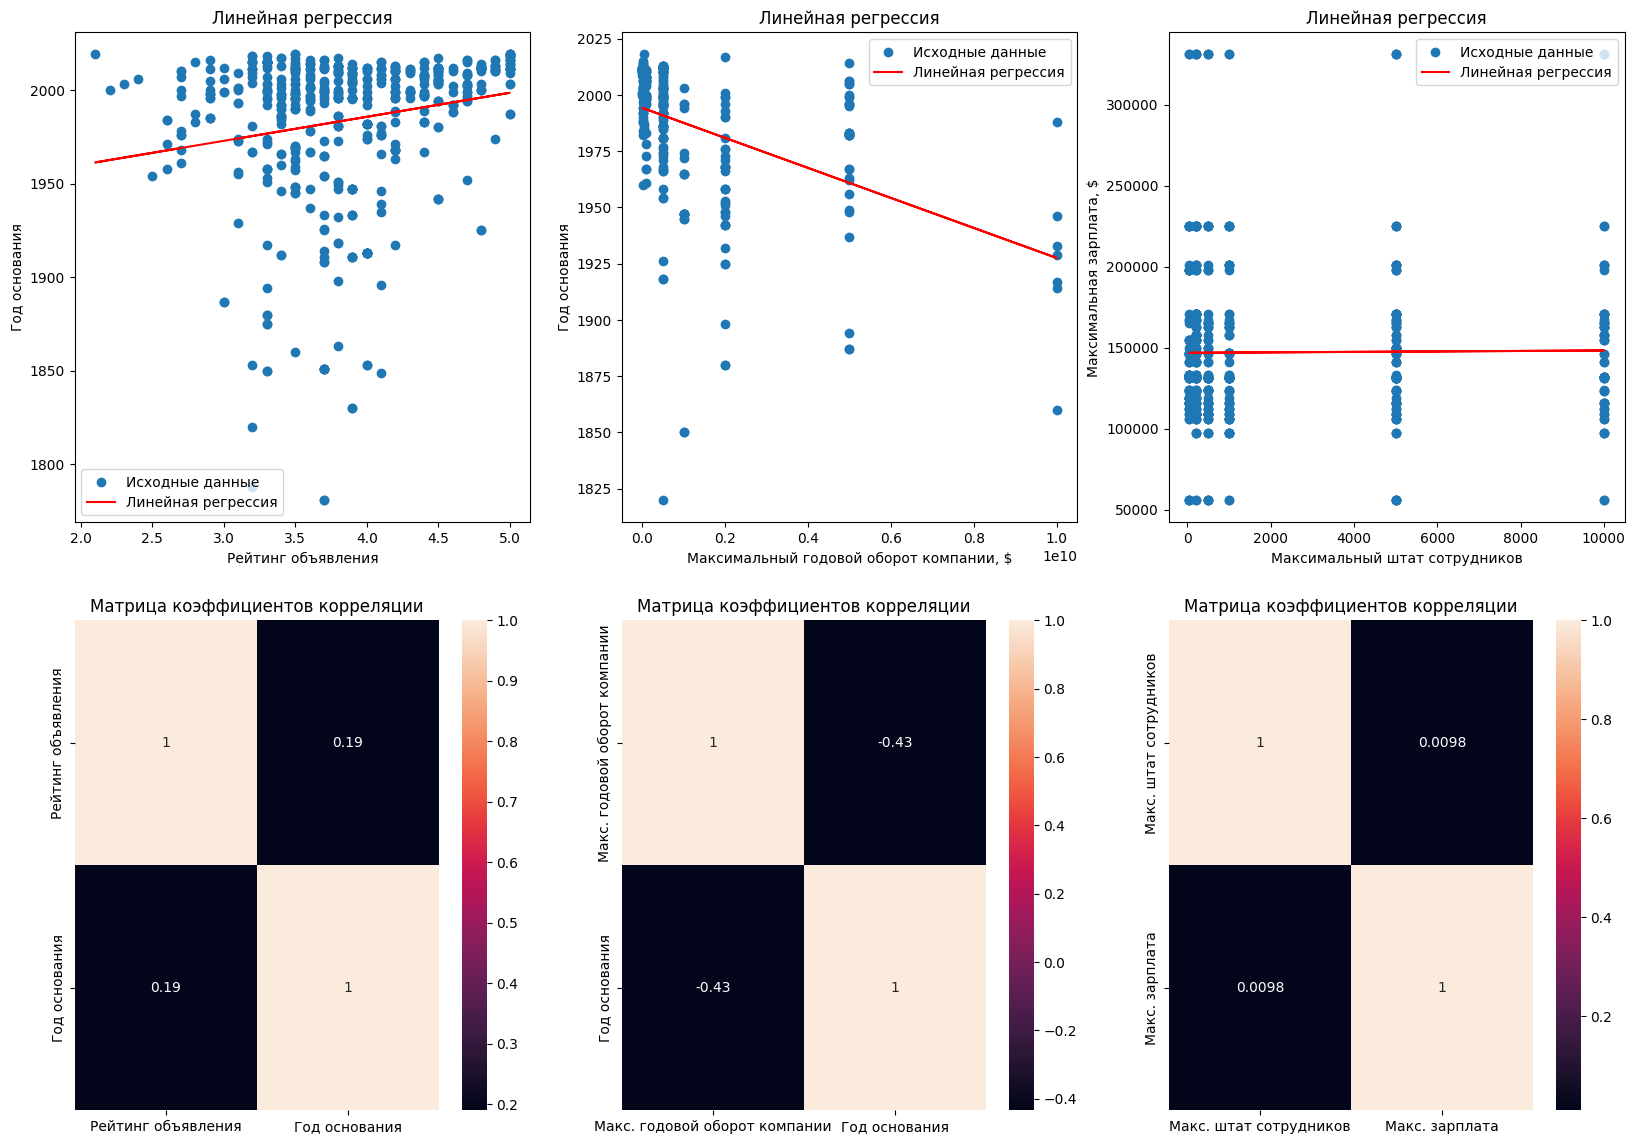

In [ ]:
# Импортируем необходимые пакеты
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt

matrix1 = pd.DataFrame([df['Rating'], df['Founded']]).transpose().query('Rating != "Unknown"').query('Founded != "Unknown"')  # Создадим матрицу в формате DataFrame с данными по рейтингу и году основания. Из созданного датасета удаляем строки, содержащие значения Unknown, посколько они помешают расчёту корреляций

matrix2 = pd.DataFrame([df['Max Revenue'], df['Founded']]).transpose().query('Founded != "Unknown"').query('`Max Revenue` != "Unknown"')  # Создадим матрицу в формате DataFrame с данными по году основания и годовому обороту. Из созданного датасета удаляем строки, содержащие значения Unknown, посколько они помешают расчёту корреляций

matrix3 = pd.DataFrame([df['Max Size'], df['Max Salary']]).transpose().query('`Max Size` != "Unknown"').query('`Max Salary` != "Unknown"')  # Создадим матрицу в формате DataFrame с данными по максимальным штатом и максимальной зарплатой. Из созданного датасета удаляем строки, содержащие значения Unknown, посколько они помешают расчёту корреляций

matrix1 = np.array([matrix1['Rating'].to_numpy(),
                    matrix1['Founded'].to_numpy()], dtype=float)  # Переводим матрицу из DataFrame в формат NumPy Array

matrix2 = np.array([matrix2['Max Revenue'].to_numpy(),
                    matrix2['Founded'].to_numpy()], dtype=float)  # Переводим матрицу из DataFrame в формат NumPy Array

matrix3 = np.array([matrix3['Max Size'].to_numpy(),
                    matrix3['Max Salary'].to_numpy()], dtype=float)  # Переводим матрицу из DataFrame в формат NumPy Array

slope1, intercept1, r1, p1, stderr1 = sp.stats.linregress(*matrix1)  # Получаем значения коэффициентов для построения линейной регрессии

slope2, intercept2, r2, p2, stderr2 = sp.stats.linregress(*matrix2)  # Получаем значения коэффициентов для построения линейной регрессии

slope3, intercept3, r3, p3, stderr3 = sp.stats.linregress(*matrix3)  # Получаем значения коэффициентов для построения линейной регрессии

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(20,14))  # Подготавливаем среду для построения графика линейной регрессии с исходными данными

# Строим графики исходных данных
ax1.scatter(*matrix1, label='Исходные данные')  # Для первой пары
ax2.scatter(*matrix2, label='Исходные данные')  # Для второй пары
ax3.scatter(*matrix3, label='Исходные данные')  # Для третьей пары

# Строим графики линейных регрессий
ax1.plot(matrix1[0], intercept1 + slope1 * matrix1[0], label='Линейная регрессия', color='red')  # Для первой пары
ax2.plot(matrix2[0], intercept2 + slope2 * matrix2[0], label='Линейная регрессия', color='red')  # Для второй пары
ax3.plot(matrix3[0], intercept3 + slope3 * matrix3[0], label='Линейная регрессия', color='red')  # Для третьей пары

# Указыаем подписи и легенду графиков для первой пары
ax1.set_xlabel('Рейтинг объявления')
ax1.set_ylabel('Год основания')
ax1.legend(facecolor='white')
ax1.set_title('Линейная регрессия')

# Указыаем подписи и легенду графиков для второй пары
ax2.set_xlabel('Максимальный годовой оборот компании, $')
ax2.set_ylabel('Год основания')
ax2.legend(facecolor='white')
ax2.set_title('Линейная регрессия')

# Указыаем подписи и легенду графиков для третьей пары
ax3.set_xlabel('Максимальный штат сотрудников')
ax3.set_ylabel('Максимальная зарплата, $')
ax3.legend(facecolor='white')
ax3.set_title('Линейная регрессия')

corr_map1 = sns.heatmap(np.corrcoef(matrix1), annot=True, ax=ax4, xticklabels=['Рейтинг объявления', 'Год основания'], yticklabels=['Рейтинг объявления', 'Год основания'])  # Визуализируем матрицу коэффициентов корреляции по Пирсону для первой пары
ax4.set_title('Матрица коэффициентов корреляции')

corr_map2 = sns.heatmap(np.corrcoef(matrix2), annot=True, ax=ax5, xticklabels=['Макс. годовой оборот компании', 'Год основания'], yticklabels=['Макс. годовой оборот компании', 'Год основания'])  # Визуализируем матрицу коэффициентов корреляции по Пирсону для второй пары
ax5.set_title('Матрица коэффициентов корреляции')

corr_map3 = sns.heatmap(np.corrcoef(matrix3), annot=True, ax=ax6, xticklabels=['Макс. штат сотрудников', 'Макс. зарплата'], yticklabels=['Макс. штат сотрудников', 'Макс. зарплата'])  # Визуализируем матрицу коэффициентов корреляции по Пирсону для третьей пары
ax6.set_title('Матрица коэффициентов корреляции')
plt.show()

Помимо анализа корреляций можно провест текстовый анализ описаний должностей (колонка Job Description), а именно узнать частотность слов. Эти данные полезны для широкого круга задач: выявление тематик, поиск паттернов составления текста, SEO и др.

Для проведения такого частотного анализа будем использовать библиотеку `nltk`. С помощью токенайзера и лемматайзера приведём описания должностей к нормальному виду. Затем с помощью счётчика `Counter` посчитаем частоты, по полученным данным построим график частот с помощью Matplotlib.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Text(0.5, 1.0, '10 самых частотных слов')

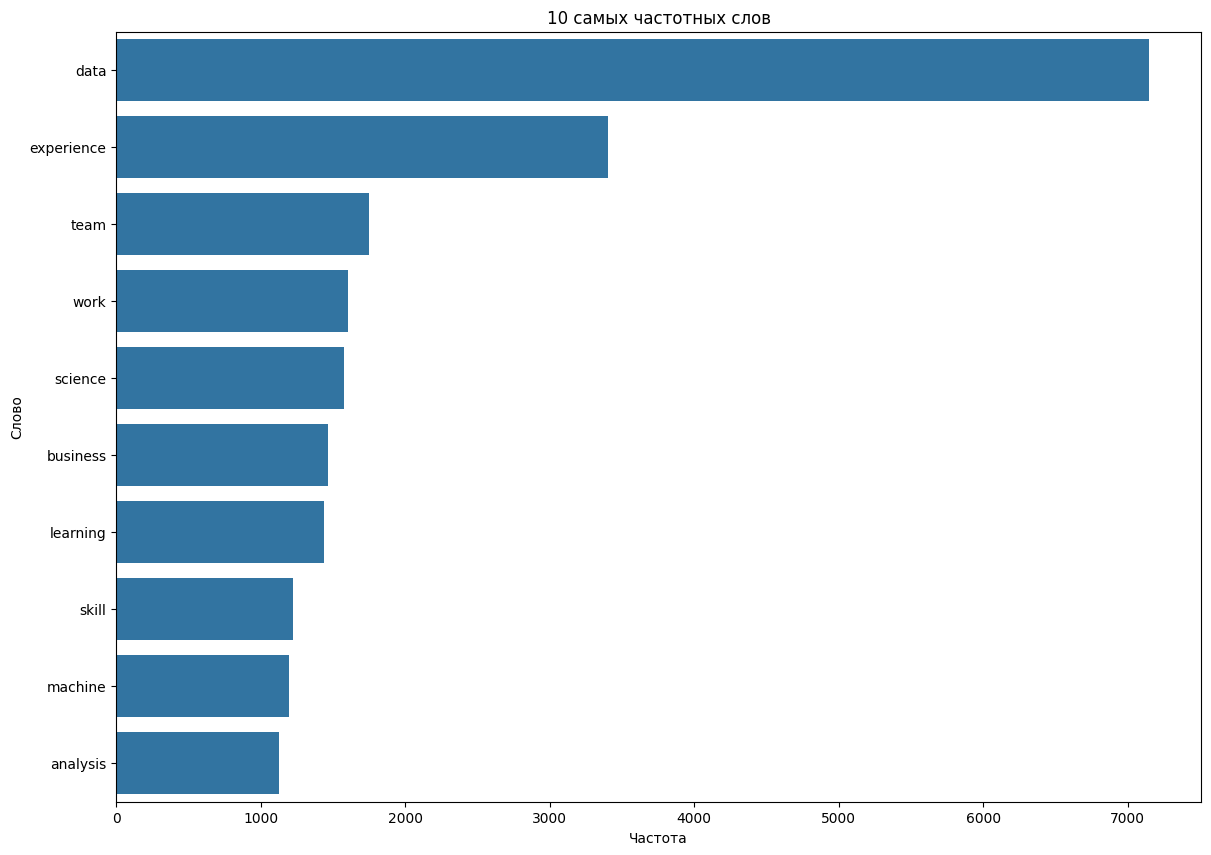

In [ ]:
import nltk  # Импортируем пакет для текстового анализа
from nltk.corpus import stopwords  # Импортируем стоп-слова для обработки текста
from nltk.tokenize import word_tokenize  # Импортируем токенайзер для вычленения слов
from nltk.stem import WordNetLemmatizer  # Импортируем лемматайзер для приведения слов к их леммам
from collections import Counter  # Импортируем счетчики для подсчета частот

# Загрузим стоп-слова для английского языка
nltk.download('stopwords')

# Для удобства определим функцию для поиска частот слов
def word_frequency(sentences: list) -> pd.DataFrame:
    sentence = " ".join(sentences)  # Соединяем все предложения из списка в одну строку
    new_tokens = word_tokenize(sentence)  # Вычленяем слова

    new_tokens = [t.lower() for t in new_tokens]  # Переводим в нижний регистр все буквы
    new_tokens =[t for t in new_tokens if t not in stopwords.words('english')]  # Находим осмысленные слова в тексте
    new_tokens = [t for t in new_tokens if t.isalpha()]  # Проверяем, что в словах нет цифр

    lemmatizer = WordNetLemmatizer()
    new_tokens =[lemmatizer.lemmatize(t) for t in new_tokens]  # Приводим слова к нормальному виду - к их леммам
    counted = Counter(new_tokens)
    word_freq = pd.DataFrame(counted.items(), columns=['Слово','Частота']).sort_values(by='Частота', ascending=False)  # Создаем массив частот слов
    return word_freq

sentences = df['Job Description'].to_list()  # Формируем список описаний должностей

data = word_frequency(sentences)  # Вызываем функцию поиска частот слов

fig, ax = plt.subplots(figsize=(14, 10))  # Создаем среду для построения графика частот слов
sns.barplot(ax=ax, x='Частота', y='Слово', data=data.head(10))  # Строим график частот для первых 10 самых частотных слов в виде гистограммы
ax.set_title('10 самых частотных слов')

### Выводы

Из полученных графиков видно, что пара рейтинг объявления - год основания компании имеет низко-положительную взаимосвязь, то есть рост одной из величин мало влияет на рост другой и наооборот. Статистически эти показатели незаметно влияют друг на друга.

Пара максимальный годовой оборот компании - год её основания имеет также достаточно низкую, но отрицательную взаимосвязь, то есть рост одной величины ведёт к спаду другой и наоборот. С особой осторожностью можно сделать вывод, что чем старее компания, тем больше будет её годовой оборот.

Для пары максимальный штат сотрудников - максимаольная заработная плата связь практически равна нулю. Иными словами, на данном датасете статистически величина штата сотрудников никак не влияет на размер заработной платы.

Частотный анализ слов показал, что наиболее часто используемым словом является data. Следующим идёт слово experience и третьим - team. Если бы мы не имели описаний работ, а владели бы только данными частотного анализа, то могли бы с уверенностью сказать, что работы в объявлениях, завязанны на анализе данных, при этом предполагается командная работа. От соискателя требуются, вероятно, навыки в машинном обучении, data science и, возможно, понимание бизнес-модели компании.

## 4 Общий вывод

В результате анализа датасета, содержащего объявления о найме на должность аналитика данных, был проведены корреляционный, регрессионный и частотный анализы.

Перед проведением анализов в датасеты было проведено предварительное исправление формата данных. Из колонок содержащих смешанный формат данных удалось извлечь более полезные числовые данные. Так, были получены данные о максимальном и мимальном размере зарабатной платы, штате сотрудников и годовом обороте компании.

Для получения полезной информации о датасете был проведён корреляционный и регрессионный анализ для пар величин:

1. рейтинг объявления - год основания компании
2. максимальный годовой оборот компании  - год её основания
3. максимальный штат сотрудников - максимальная заработная плата

Эти исследования показали, что третья пара величин не имеет никакой статистической взаимосвязи; первая пара имеет положительную взаимосвязь, которая достаточно плохо выражена; вторая пара имеет отрицательную взаимосвязь, её коэффициенты корреляции также низки $(>-0.5)$, тем не менее можно с осторожностю говорить о том, что для более старых компаний характерна более высокая доходность. Ниже приведены график с линейной регрессией для этой пары и корреляционная матрица.

![Regression chart and correlation matrix](https://lh3.google.com/u/0/d/1UVsQoQz1hTAmH4j35yOwBCdIC7VfX5vk=w1365-h927-iv1?auditContext=forDisplay)

Помимо регрессионного и корреляционного анализов был проведён анализ частот слов из описаний должностей. Он показал, что самым частотным словом оказалось data, которое встретилось более 6500 раз. Следующим за ним идёт experience (3500 раз). Остальные слова встречаются от 2000 раз и менее. Ниже приведён график с 10 самыми частотными словами.

![](https://lh3.google.com/u/0/d/18LuzkOdgvGNFbKPSU-dy_TW8AFGJFX6u=w1920-h927-iv1?auditContext=prefetch)

Не проводя глубокого изучения, а имея только частоты слов можно уже утверждать, что работадатели ищут командных сотрудников, обладающих опытом и навыками в машинном обучении и data science

________________________________________________________________________________

# Часть вторая: Работа с моделями для прогноза

## План работы

- Подготовить датасет
- Разметить данные датасета
- Настроить модель для обучения
- Обучить модель
- Провести валидацию модели
- Провести прогнозирование на неразмеченных данных
- Сделать выводы

## 1 Подготовка датасета для ML

В части работы, посвящённой машинному обучению (англ. аббр. ML), обучим нейронную сеть распознаванию структур на поверхности материала, то есть решим одну из задач компьютерного зрения.

Задача состоит в классификации объектов на поверхности полупроводникового материала на изображениях (сканах), полученных на атомно-силовом микроскопе. Пример разметки скана приведён на рисунке ниже.

![Разметка сканов АСМ](https://lh3.googleusercontent.com/fife/ALs6j_E1yEwrx-qBelcEiBVZLnTpjPm88TqgoXnej_KASJSOv3ywYuGokLymetvQBR_p6DiIi9Awf86EO5RWMSy3ktUVeTIVOeX6RUgXUVmiwlaflWF9ThyaV7JBqWzPn7IyWfzZ8VYgefgae0MX05PwDtkyfaGJKddI3BAL6wsRualj5vkA6xcwmjREf9GG97ejnWZnBw03m7x-gntqsShMe_p77BoyOu_9zd59TF49MvtZVeL5nNk3StrbRGS-x_VTbpQJkXIlkTzunypcpnAS-J_5lUL6vQ5hjUvFLgDje5-3QFAv2hSFjLg31e0vz2c9iD90mGnIsNK3_hdGM7eXnTL4RN4hXSDWj6afGRwTheMbVO81DCGOaE74uJqxFJE85eYaYSg93zRSSozmSenHd9HvU88quIYmJ4CD2MpFGY2VC8bhmgZ60GO9FXO4Aae75Y2uOvxad5vAGFZv4eruIeM9Vvw--zd9PQrxtbp7YTTGc_zi5vW5QEgHILu0fkALQH_9vV6xbv4WBg93lfDzlds47p01dsrLHtaFk6X9dEGsK9nxnYAgW3jhgOYS_xLytf0uNy5CLUuC01KN4iC9NQQCX8mlrAHCdWxXcjBEq1EXj1rjttl184gK-HrnEzL505WDhRyDmMIVdFB7zwEldD00KiM8vwk-qOYcOFyqgyN13Uxah36RDip4yBjpGrUPzKfoMIvWNciFdx6KVMGsNw5zbhTRhfRNHrCbc4QqIoRouVXiZXWhzW5i-kL-dDy5J5EB26y_d8vsKlWZ_vYtcez2rRySNvtlrjWjU4cngFn16c_8Ad_wZPH8KSH11GdRKnrL_5bhU8ioEWSd_pZtGb1c5wL3b_FjebQhOETuiBCq3fKwCc3-GW4GCTbfSL979nS84-tlL-ZcVF7CFGw1B_Y_XE3zptVai0_bFTk9i-Gs3tmJh1aAaj7-othgLkW8z8NctBA6hmVFCM3GaWTUR5-47osY7HYNtFoAYZcgDJm5PB7hzmIfNfKWdG9PYrjdSmGx5COzt7dLyqObAiPSKsYWiuoz5Q2APzKcibEAeYUx26ht5C6v1etA0pzC9N-QzX71zbZIFX_iAmNpygcSqaVMooU6fnwUQ_0Teea4iu6d10zIfFnMOVp4mm8cSD-_uMJPqA_8Vf_9wr9HsTG1L59D0IiqMD4aqW_S44rVFVWzmwX5z65kf9Gnyq-U6N8gbVm5F_P1P3C0xbJe6_6HEGMbe6o7mXjS5oY3TkiVFXOtDZu8MaPdLPqTYoJXkrHMd45rYEykkKj5T-8bqAhlmv4-jd-L8pluLAv23CWV8L4zIURk32bQKnoRPQCqN9p_RL2WAQ09cdlmVtlj9gECKEKQmjiZFWgv_Gov5ty8HMKmRGHY47L0QPt4vkJBHJesIWqSdFwYO4Dh_tA47Ndg-K_4caq1g6bsFcI776BeY43CHAZ2e2ecYrYVWcXkyqojMggyZfz6dfwobd58H_v6Isp-dXzBKiRU96HWpQ-bXqQaAW307EqNT9DGw6TKqoQaypdPJCGI5AXSEZrQJt95S9IVNltxPqrrDh6dhihxkt2GWKjk_Q_PMei6bhZutDgULETPRVHaMLsdhmFswJVObKdbku1V14gyAMm9LUVnOEkh=w1000-h900?auditContext=prefetch)

В качестве данных выступают сканы поверхностей образцов полупроводника. Сканы имеют размер 256x256 пикселей и исполнены в оттенках серого. Всего в датасете содержится 83 скана, из них 71 скан отведён на обучение, 14 на валидацию и 12 для прогнозирования (тестов). Карта распределения сканов по выборкам доступна по [ссылке](https://drive.google.com/file/d/1WwIjRi0n36ZwYQNY5JY_GFinGVogapyz/view?usp=drive_link). На карте номера в колонке указывают на соответствующие названия сканов, а цвета их выделения на выборку. Исходные сканы датасета содержатся в [директории](https://drive.google.com/drive/folders/1d9HyosWvBEcxU1cgU5vZOEeAWjaMEsel?usp=drive_link). Датасет доступен по [ссылке](https://drive.google.com/drive/folders/1pzhuQMGVQdT-z4f0iCtMQT3a2hNzDlsc?usp=drive_link).

Стандартом в компьютерном зрении являются алгоритмы на основе свёрточных нейронных сетей. Одним из самых популярных алгоритмов в задачах обнаружения объектов является YOLO (англ. You Only Look Once), а одной из самых популярных реализацией для питона является пакет от [Ultralytics](https://github.com/ultralytics/ultralytics).

Перед обучением модели на датасете, его необходимо подготовить, то есть провести разметку обучающих данных. Разметку можно сделать в приложении [Label Studio](https://labelstud.io/).

После разметки по мимо датасета изображений появится датасет с разметочными данными, который для каждого скана содержит текстовый файл с указанием всех меток (названий классов) объектов, изображённых на нём.

В данном датасете выделяется 4 класса объектов:

- Холм
- Яма
- Артефакт
- Скол

Для загрузки датасета в среду выполнения, его необходимо скачать с https://drive.google.com/drive/folders/1pzhuQMGVQdT-z4f0iCtMQT3a2hNzDlsc?usp=sharing. Затем датасет необходимо добавить в раздел Файлы блокнота с сохранением файловой структуры датасета. Либо можно скачать zip архив датасета, загрузить его в Файлы и выполнить команду

In [ ]:
!unzip ./dataset.zip

Archive:  ./dataset.zip
   creating: labels/
   creating: labels/train/
  inflating: labels/train/f7154d9e-79.txt  
  inflating: labels/train/7c316f29-12.txt  
  inflating: labels/train/24df4f60-23.txt  
  inflating: labels/train/bc245130-1.txt  
  inflating: labels/train/51874fb9-20.txt  
  inflating: labels/train/bbdb68f3-32.txt  
  inflating: labels/train/6c33618e-33.txt  
  inflating: labels/train/0f2a3f15-68.txt  
  inflating: labels/train/2f93c9eb-2.txt  
  inflating: labels/train/07d0a217-36.txt  
  inflating: labels/train/8e3399ce-17.txt  
  inflating: labels/train/7ccd05fa-46.txt  
  inflating: labels/train/6b70356b-60.txt  
  inflating: labels/train/30a39bd9-50.txt  
  inflating: labels/train/034bff7e-70.txt  
  inflating: labels/train/9b56c465-24.txt  
  inflating: labels/train/45c1b95e-22.txt  
  inflating: labels/train/43c4785c-61.txt  
  inflating: labels/train/9e0f5459-66.txt  
  inflating: labels/train/55f8c293-7.txt  
  inflating: labels/train/78f8ea37-5.txt  
  inflat

Для проверки откроем пару сканов датасета.

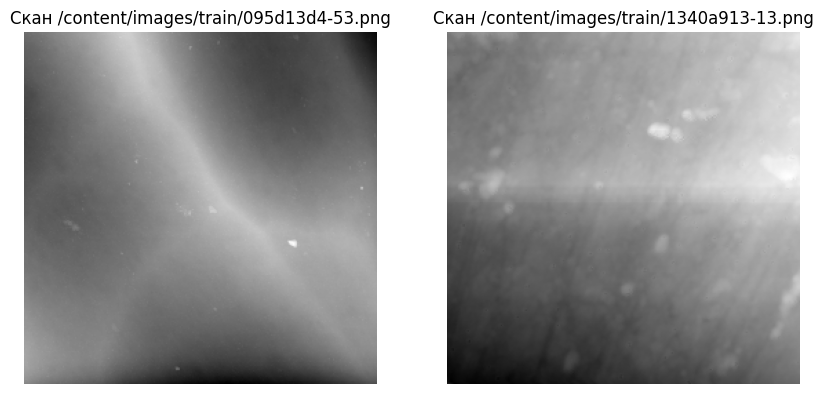

In [ ]:
# Импортируем библиотеку matplotlib для построения графики
import matplotlib.pyplot as plt
import matplotlib.image as mpimg # Импортируем модуль для работы с растровой графикой

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 10)) # Создаём среду для построения графики
img1 = mpimg.imread('/content/images/train/095d13d4-53.png') # Читаем файл скана 1
img2 = mpimg.imread('/content/images/train/1340a913-13.png') # Читаем файл скана 2
ax1.imshow(img1, cmap='gray') # Подготавливаем скан 1 к выводу
ax2.imshow(img2, cmap='gray') # Подготавливаем скан 2 к выводу
ax1.set_title('Скан /content/images/train/095d13d4-53.png') # Добавляем адрес файла скана 1
ax2.set_title('Скан /content/images/train/1340a913-13.png') # Добавляем адрес файла скана 2
ax1.axis('off') # Убираем отображение осей на скане 1
ax2.axis('off') # Убираем отображение осей на скане 2
plt.show() # Выводим сканы

### Результаты

Подготовили датасет для решения задачи компьютерного зрения, состоящий из сканов атомно-силового микроскопа, по поиску объектов:

- Холм
- Яма
- Артефакт
- Скол

Разбили датасет на обучающую, валдационную и тестовую выборки.

Провели разметку сканов для обучения модели.

## 2 Подготовка и обучение модели

Устанавливаем через утилиту pip пакет от Ultralytics для настройки нейросети.

In [ ]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 57.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

Настраиваем нейросеть и запускаем её обучение.

In [ ]:
from ultralytics import YOLO # Импортируем класс для создания нейросети и её обучения
from ultralytics import settings # Импортируем методы настроек YOLO


settings.update({"datasets_dir": "/content"}) # Меняем путь к корневой директории датасетов на директорию /content

model = YOLO("yolo11n.yaml") # Импортируем файл настроек модели YOLO11n в формате YAML в нашу модель

model.info() # Выведем базовую информацию о модели

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO11n summary: 181 layers, 2,624,080 parameters, 2,624,064 gradients, 6.6 GFLOPs


(181, 2624080, 2624064, 6.614336)

Видно, что модель имеет 181 слой и больше 2,5 млн параметров. Иными словами, решение задачи компьютерного зрения будет осуществляться через глубокое обучение свёрточной нейронной сети.

In [ ]:
# Вызываем метод обучения модели
model.train(data='/content/dataset.yaml', # Указываем путь к файлу с настройками датасета
            epochs=100, # Задаём количество эпох обучения: количество проходов датасета вперёд-назад за весь период обучения сети - длительность обучения
            imgsz=256, # Задаём размер картинки, к которому нужно свести размеры картинок датасета
            val=True, # Указываем, что во времяобучения необходимо валидировать результаты
            optimizer='auto', # Задаём алгоритм оптимизации - процедура синхронной настройки весов модели во время обучения, необходим для минимзации ошибок модели, увеличивая скорость схождения и повышая устойчивость
            lr0=0.01, # Задаём скорость обучения - шаг изменения веса во время обучения
            weight_decay=0.0005, # Задаём штраф для веса, чтобы предотвратить переобучение. Используемый метод - L2 регуляризация
            momentum=0.937) # Коэффициент оптимизатора, задающий влияние градиентов прошлой итерации в данной эпохе на градиенты в текущей итерации

Ultralytics 8.3.147 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=Tru

100%|██████████| 22.2M/22.2M [00:00<00:00, 111MB/s] 

Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

 23        [16, 19, 22]  1    431452  ultralytics.nn.modules.head.Detect           [4, [64, 128, 256]]           
YOLO11n summary: 181 layers, 2,590,620 parameters, 2,590,604 gradients, 6.4 GFLOPs

Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


100%|██████████| 5.35M/5.35M [00:00<00:00, 102MB/s]


...

                   all         14         47      0.566      0.287       0.31      0.144



100 epochs completed in 0.030 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 5.4MB
Optimizer stripped from runs/detect/train/weights/best.pt, 5.4MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.147 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 11.21it/s]


                   all         14         47      0.573      0.287      0.316      0.153
              Артефакт          9         22       0.47      0.182      0.202     0.0576
                  Скол          3          7          1          0      0.106      0.024
                  Холм          2          4      0.273       0.25      0.296      0.248
                   Яма          3         14      0.548      0.714      0.661      0.284
Speed: 0.1ms preprocess, 1.2ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f987725ed10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

Файлы YAML содержат настройки среды обучения и работы моделей.

Если мы определяем настройки архитектуры модели, то необходимо указать, например, следующие параметры:

- `task: (detect | segment | classify | pose | obb)` - определяет вид целевой задачи для обучения модели
- `mode: (train | val | predict | export | track | benchmark)` - вид работы модели: обучать, валидировать, прогнозировать, экспортировать модель, отслеживать объекты (см. task), тестировать производительность модели
- `data: /путь/к/yaml/файлу/с/настройками/датасета`
- `epochs: 100` - число эпох обучения модели

Список значений по умолчанию можно найти на [GitHub проекта](https://github.com/ultralytics/ultralytics/blob/a7910a9a077a5b052df60877b214ed3462884bcb/ultralytics/cfg/default.yaml).

Если определяются настройки датасета, то в них нужно указать как минимум следующие параметры:

```yaml
path: /content # Корневая директория датасета
train: images/train # Директория с картинками для обучения модели относительно path
val: images/valid # Директория с картинками для валидации (path)/(val)
test: images/test # Директория с картинками для теста (path)/(val)

# Классы
names:
  0: Артефакт
  1: Скол
  2: Холм
  3: Яма
```

Формат модели YOLO требует, чтобы файловая система датасета имела следующую структуру

```
images
├── train
├── val
└── test
labels
├── train
├── val
└── tests
```
Именно структуру - не имена (их можно поменять).

После обучения сети (заметим, что обучение примерно в 5 раз дольше на CPU платформе, чем на GPU) в рабочей директории появится папка runs, в ней содержатся результаты обучения сети на конкретную задачу, в наше случае - на обнаржение объектов (папка detect). В папке detect хранятся папки с результатим выполнения задач: обучение, валидация, прогноз, экспорт... В наше случае при первом обучении, его результаты будут в папке train. Она содержит графики метрик результаты валидации, а также батчи, на которые бился датасет при прогоне в каждой эпохе, там же отображена разметка сканов.

В папке train из основных файлов будут

- /content/runs/detect/train/val_batch0_pred.jpg - содержит результат конечной валидации, то есть это предсказания модели на размеченных сканах для валидации (14 штук)
- /content/runs/detect/train/val_batch0_labels.jpg - содержит разметку сканов, предназначенных для валидации
- /content/runs/detect/train/results.png - ключевые графики, отражающие процесс обучения модели

Ниже приведены эти файлы.

![Исходная разметка сканов валидации](https://lh3.google.com/u/0/d/1D8pCk2PkJkA8J-2K5mPazFoZUissl-tl=w1600-h900-iv1?auditContext=prefetch)

![Прогноз модели при валидации на размеченных сканах](https://lh3.google.com/u/0/d/11govs5-9LMnx9OexHh9K1oyIhz_UqgTT=w1600-h900-iv1?auditContext=prefetch)

![Графики, отражающие обучение модели](https://lh3.google.com/u/0/d/1dLjlSek_vTc4ebHSSE1la79FPNpY5-wz=w1600-h900-iv1?auditContext=prefetch)

### Выводы

Видно, что в валидационный датасет вошли сканы со всеми видами классов объектов. Однако, модель в основном нашла объекты только двух классов: яма и артефакт. Это связано с самой разметкой сканов, поскольку на сканах больше всего было именно объектов этих двух классов. [Ссылка](https://drive.google.com/file/d/1dNLdQ6Hjb87FEnNKys5SlDbRMMMPhdFG/view?usp=drive_link) на размеченные сканы в формате JSON (просмотреть можно в бесплатном [Label Studio](https://labelstud.io/)).

Взглянем на рисунок с графиками выше.

Первые три графика сверху отражают потери при обучении, а снизу - изменение потерь во время валидации (100 эпох, ось абсцисс). Верный признак того, что модель обучается является снижение значения потерь, то есть минимизация функции потерь, что отчетливо видно на графиках.

Оставшиеся 4 графика отражают ключевые метрики модели, точность (англ. precision), отклик (англ. recall) и mAP (англ. Mean Average Precision), которая основывается сразу на нескольких параметрах: точности, отклике, матрице ошибок и  IoU (пересечение над объединением). Рост точности, отклика и mAP, также явно показывает, что модель оптимизирует свои веса под данные.

## 3 Проверка модели на неразмеченных данных

Проведём проверку модели на неразмеченных сканах из /content/images/test.

['/content/images/test/5deae1c8-42.png', '/content/images/test/83.png', '/content/images/test/56.png', '/content/images/test/21.png', '/content/images/test/09dee145-45.png', '/content/images/test/fda9f403-35.png', '/content/images/test/7fe19b96-48.png', '/content/images/test/cf735861-43.png', '/content/images/test/65.png', '/content/images/test/ffed1e1f-44.png', '/content/images/test/78.png', '/content/images/test/34364880-40.png']

image 1/1 /content/images/test/5deae1c8-42.png: 256x256 (no detections), 27.2ms
Speed: 1.0ms preprocess, 27.2ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train2


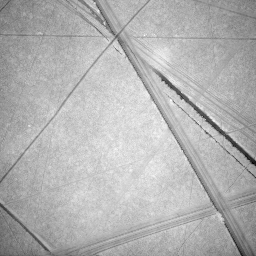


image 1/1 /content/images/test/83.png: 256x256 2 Ямаs, 16.9ms
Speed: 0.7ms preprocess, 16.9ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train3


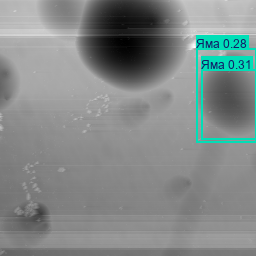


image 1/1 /content/images/test/56.png: 256x256 1 Артефакт, 12.7ms
Speed: 0.7ms preprocess, 12.7ms inference, 1.8ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train4


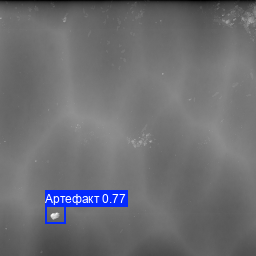


image 1/1 /content/images/test/21.png: 256x256 (no detections), 11.9ms
Speed: 0.6ms preprocess, 11.9ms inference, 0.8ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train5


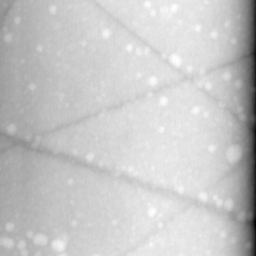


image 1/1 /content/images/test/09dee145-45.png: 256x256 1 Яма, 16.4ms
Speed: 0.6ms preprocess, 16.4ms inference, 1.8ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train6


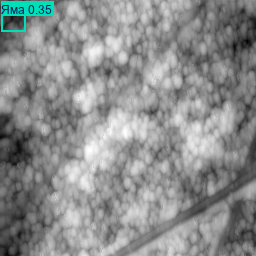


image 1/1 /content/images/test/fda9f403-35.png: 224x256 1 Яма, 22.6ms
Speed: 0.6ms preprocess, 22.6ms inference, 1.8ms postprocess per image at shape (1, 3, 224, 256)
Results saved to runs/detect/train7


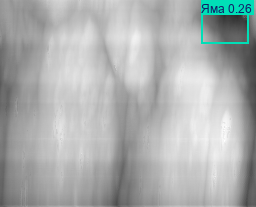


image 1/1 /content/images/test/7fe19b96-48.png: 256x256 (no detections), 13.0ms
Speed: 2.5ms preprocess, 13.0ms inference, 0.8ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train8


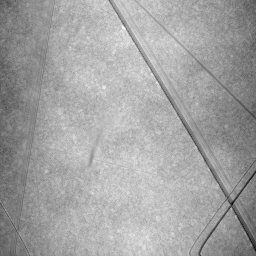


image 1/1 /content/images/test/cf735861-43.png: 256x256 (no detections), 11.5ms
Speed: 0.6ms preprocess, 11.5ms inference, 1.2ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train9


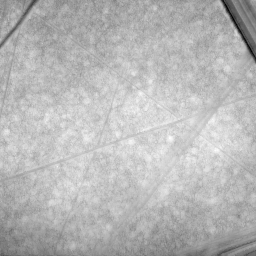


image 1/1 /content/images/test/65.png: 256x256 (no detections), 12.5ms
Speed: 0.6ms preprocess, 12.5ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train10


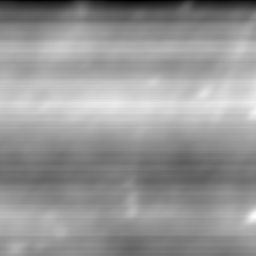


image 1/1 /content/images/test/ffed1e1f-44.png: 256x256 (no detections), 14.2ms
Speed: 0.6ms preprocess, 14.2ms inference, 0.9ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train11


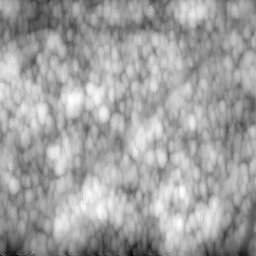


image 1/1 /content/images/test/78.png: 256x256 (no detections), 15.3ms
Speed: 0.7ms preprocess, 15.3ms inference, 0.8ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train12


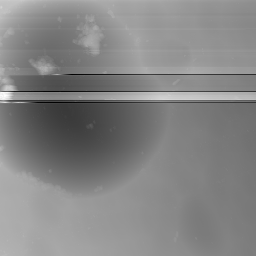


image 1/1 /content/images/test/34364880-40.png: 256x256 (no detections), 12.4ms
Speed: 0.7ms preprocess, 12.4ms inference, 0.8ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train13


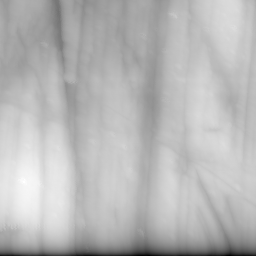

In [ ]:
import os # Импортируем модуль os для работы с файлами

path = r'/content/images/test/'
paths = [path+f for f in os.listdir(path)] # Получим полные адреса тестовых сканов
print('Адреса тестовых сканов:', paths)

# Проведём прогноз на неразмеченных сканах
for path in paths:
    predictions = model.predict(path, save=True) # Предсказываем классы на сканах
    for pred in predictions:
        pred.boxes # Добавляем рамки к найденными объектам
        pred.show() # Выводим обработанные сканы

### Выводы

Из 12 тестовых сканов модели удалось предсказать 4:

![](https://lh3.google.com/u/0/d/1FnNj6rDcCO080G5QWSS0idtTyNOsLPCD=w1600-h900-iv1?auditContext=prefetch)

![](https://lh3.google.com/u/0/d/1Lxl8XEtrESt24BdRLXTghjEIY0GP5H4k=w1600-h900-iv1?auditContext=prefetch)

![](https://lh3.google.com/u/0/d/16wirTbkmWTMbukewBqXnC7-8ysihznBY=w1600-h900-iv1?auditContext=prefetch)

![](https://lh3.google.com/u/0/d/16J6oSxg9xbVAERYwfV9x4xKOAy6VfHm9=w1600-h900-iv1?auditContext=prefetch)

Стоит отметить, что на первом скане трудно выделить объекты, относящиеся к одном из 4 определённых классов. Однако, модель распознала в левом верхнем углу яму.

На втором скане присутствуют и артефакты и ямы. Модели удалось найти только артефакт с высокой степенью уверенности.

На третьем модель нашла две ямы в области, где присутствует только одна, при этом она пропустила другую более заметную яму.

На четвёртом скане также трудно выделить объекты из 4 классов, но модель нашла на нём яму, при степень уверенности мала $(\sim 0,3)$.

Можно заключить, что модель приобрела некоторую интуицию по обнаружению объектов на достаточно малом датасете.

## 4 Общие выводы

Обученная сверточная нейронная сеть архитектуры YOLO на датасете в 71 скан предоставляет удовлетрворительные предсказания объектов поверхности полупроводникового материала.

Использованный датасет имеет недостаточный размер для создания производительной модели. Стоит рассмотреть расширение датасета до нескольких сотен сканов.

Входе обучения было замечено, что модель хорошо распознаёт объекты, которых было размечено больше всего. Такими оказались классы артефакт и яма.

Проверка модели на тестовом датасете показала, что модель способна делать предсказания. Однако, необходимо повышать точность предсказаний с помощью увеличения датасета и предоставления разнообразных данных. Также возможно увеличение количества эпох для обучения.

Итоговые варианты модели можно найти [здесь](https://drive.google.com/drive/folders/1cyRIDuHETnphWvznz0BGQkwIVJAyc2hF?usp=drive_link). Файл best.pt содержит лучшие веса модели, полученные во время обучения. Формат файла best.pt - предобученная модель PyTorch.